<a href="https://colab.research.google.com/github/thunerous/MH/blob/main/%D0%9B%D0%A0_13_%D0%9C%D0%9D_CI%D0%94%D0%9E%D0%A0%D0%A6%D0%95%D0%92.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
imsparsh_flowers_dataset_path = kagglehub.dataset_download('imsparsh/flowers-dataset')

print('Data source import complete.')


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns

import os
from PIL import Image

import warnings
# filter warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm

In [ ]:
train_dir = '/kaggle/input/flowers-dataset/train'

In [ ]:
# Визначення трансформацій
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Автопошук train/test у /kaggle/input
train_dir = None
test_dir = None

for root, dirs, files in os.walk('/kaggle/input'):
    if os.path.basename(root) == 'train':
        train_dir = root
    elif os.path.basename(root) == 'test':
        test_dir = root

print("Знайдений train_dir:", train_dir)
print("Знайдений test_dir:", test_dir)

if train_dir is None:
    raise FileNotFoundError("Не знайдено папку train у /kaggle/input")
if test_dir is None:
    raise FileNotFoundError("Не знайдено папку test у /kaggle/input")


class CustomTestDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.directory = directory
        self.transform = transform
        self.images = []

        for filename in os.listdir(directory):
            img_path = os.path.join(directory, filename)
            if os.path.isfile(img_path):
                self.images.append(img_path)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image


# Завантаження тренувального набору
train_data = datasets.ImageFolder(train_dir, transform=transform)

# Завантаження тестового набору
test_dataset = CustomTestDataset(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Розділення тренувального набору
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

# DataLoader-и
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Інформація про датасет
print(f"Кількість класів: {len(train_data.classes)}")
print(f"Класи: {train_data.classes}")
print(f"Розмір тренувального набору: {len(train_dataset)}")
print(f"Розмір валідаційного набору: {len(val_dataset)}")
print(f"Розмір тестового набору: {len(test_dataset)}")

# Перевірка балансу класів
class_counts = {class_name: 0 for class_name in train_data.classes}
for _, label in train_data.samples:
    class_counts[train_data.classes[label]] += 1

print("\nРозподіл класів у тренувальному наборі:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")
print(f"Розмір тестового набору: {len(test_dataset)}")

Знайдений train_dir: /kaggle/input/datasets/imsparsh/flowers-dataset/train
Знайдений test_dir: /kaggle/input/datasets/imsparsh/flowers-dataset/test
Кількість класів: 5
Класи: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Розмір тренувального набору: 2196
Розмір валідаційного набору: 550
Розмір тестового набору: 924

Розподіл класів у тренувальному наборі:
daisy: 501
dandelion: 646
rose: 497
sunflower: 495
tulip: 607
Розмір тестового набору: 924


In [ ]:
# Завантаження попередньо навченої моделі
model = models.resnet18(pretrained=True)

# Заморожування параметрів моделі
for param in model.parameters():
    param.requires_grad = False

# Заміна останнього повнозв’язного шару
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5)  # 6 класів у наборі даних

# Перенесення моделі на GPU, якщо доступно
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 20
best_val_loss = float('inf')

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Валідація
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/kaggle/working/best_model.pth')

100%|██████████| 69/69 [00:53<00:00,  1.28it/s]


Epoch 1/20
Train Loss: 1.0091, Train Accuracy: 0.6239
Val Loss: 0.7144, Val Accuracy: 0.7545


100%|██████████| 69/69 [00:54<00:00,  1.26it/s]


Epoch 2/20
Train Loss: 0.5962, Train Accuracy: 0.8005
Val Loss: 0.5972, Val Accuracy: 0.7909


100%|██████████| 69/69 [00:53<00:00,  1.29it/s]


...

Epoch 18/20
Train Loss: 0.2702, Train Accuracy: 0.9062
Val Loss: 0.4406, Val Accuracy: 0.8436


100%|██████████| 69/69 [00:53<00:00,  1.29it/s]


Epoch 19/20
Train Loss: 0.2710, Train Accuracy: 0.9012
Val Loss: 0.4588, Val Accuracy: 0.8327


100%|██████████| 69/69 [00:53<00:00,  1.29it/s]


Epoch 20/20
Train Loss: 0.2484, Train Accuracy: 0.9117
Val Loss: 0.4516, Val Accuracy: 0.8473


In [ ]:
def visualize_model(model, dataloader, class_names, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(15, 10))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size(0)):
                images_so_far += 1
                ax = plt.subplot(num_images // 2 + 1, 2, images_so_far)
                ax.axis('off')
                ax.set_title(
                    f'predicted: {class_names[preds[j].item()]}\n'
                    f'true: {class_names[labels[j].item()]}'
                )

                inv_normalize = transforms.Normalize(
                    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
                    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
                )

                inp = inv_normalize(inputs[j].cpu()).numpy().transpose((1, 2, 0))
                inp = np.clip(inp, 0, 1)

                plt.imshow(inp)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    plt.tight_layout()
                    plt.show()
                    return

    model.train(mode=was_training)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_training_metrics(train_losses, train_accuracies, val_losses, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # График loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # График accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
all_labels = []
all_preds = []
val_loss = 0.0
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

val_loss /= len(val_loader)
val_accuracy = correct / total
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'F1 Score: {f1:.4f}')

Validation Loss: 0.4516
Validation Accuracy: 0.8473
F1 Score: 0.8479


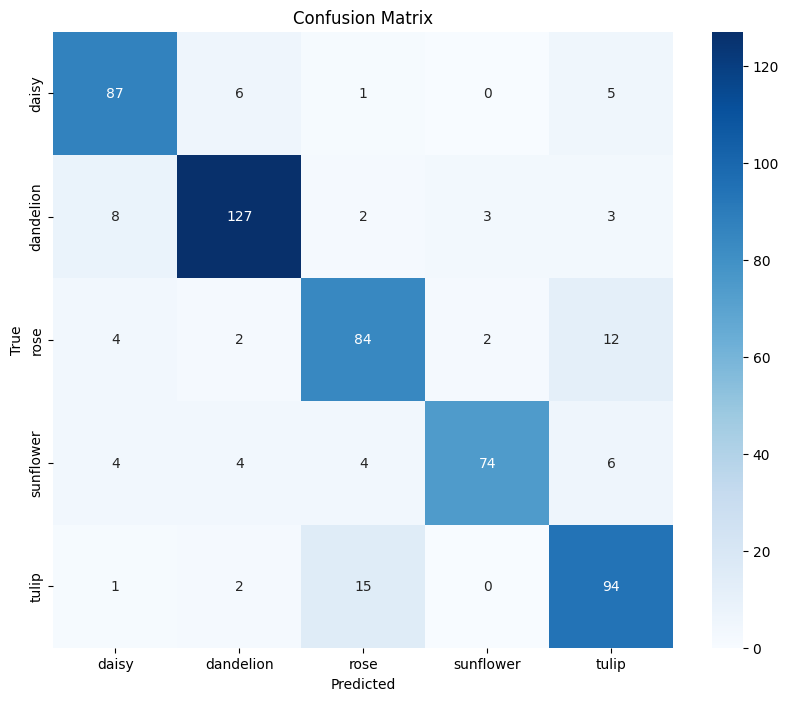

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

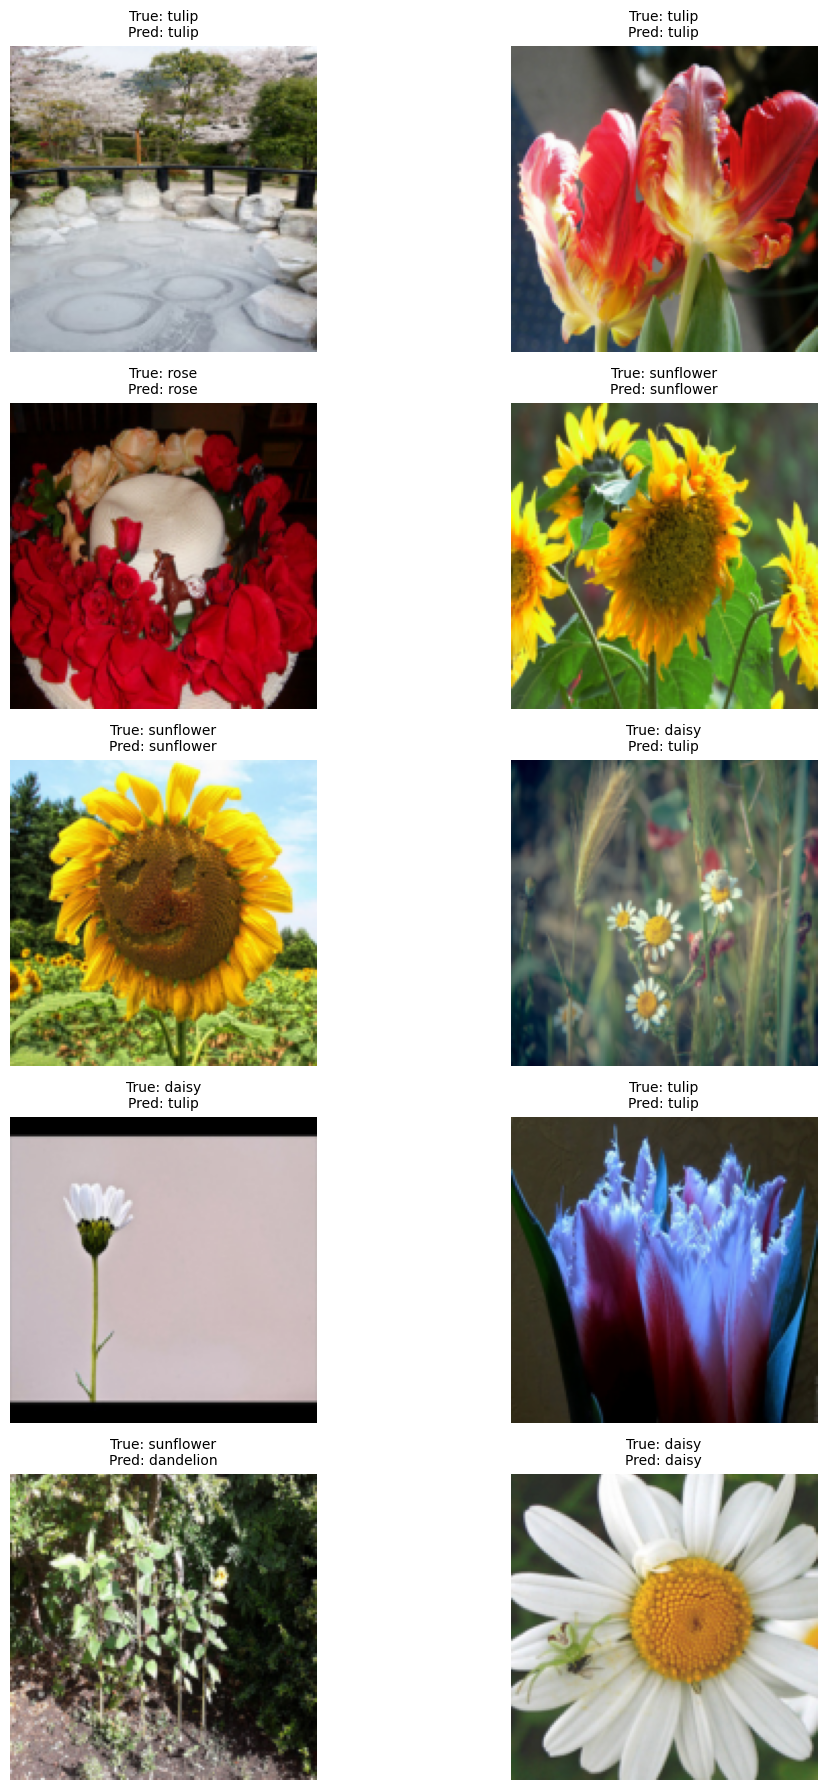

In [ ]:
# Візуалізація передбачень моделі
model.eval()
num_images = 10
shown = 0

plt.figure(figsize=(12, 18))

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        for j in range(inputs.size(0)):
            shown += 1
            ax = plt.subplot(5, 2, shown)
            ax.axis('off')
            ax.set_title(
                f"True: {train_data.classes[labels[j].item()]}\n"
                f"Pred: {train_data.classes[preds[j].item()]}",
                fontsize=10
            )

            # Денормалізація
            inv_normalize = transforms.Normalize(
                mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
                std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
            )

            img = inv_normalize(inputs[j].cpu()).numpy().transpose((1, 2, 0))
            img = np.clip(img, 0, 1)

            plt.imshow(img)

            if shown == num_images:
                plt.tight_layout()
                plt.show()
                break

        if shown == num_images:
            break